# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — Google Search Ranking & Discoverability

## Refresh / Content Opportunity Scoring

This project studies whether historical search-performance signals can be used to identify content that is likely to experience future performance decline.

The output is a ranked decision-support queue that helps content reviewers prioritize pages for review.

This analysis does not claim to predict Google's ranking algorithm or guarantee that refreshing a page will improve performance.

## 1. Question

### Research Question

Can historical search visibility, click performance, and engagement signals identify content that is likely to experience future search-performance decline?

### Decision Supported

The goal is to help a content or SEO reviewer decide which pages should be reviewed first for possible refresh or improvement.

The model produces a ranked priority queue rather than an automatic refresh decision.

### Lane

Refresh / Content Opportunity Scoring.

In [73]:
!pip install -q huggingface_hub duckdb pyarrow fsspec

from huggingface_hub import login
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

con = duckdb.connect()

con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

con.sql(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{hf_token}'
);
""")

print("FlyRank warehouse connection ready.")

FlyRank warehouse connection ready.


In [75]:
# Test whether DuckDB can read the March parquet file

march_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet"

try:
    test = con.sql(f"""
        SELECT *
        FROM read_parquet('{march_path}')
        LIMIT 5
    """).df()

    print("March 2026 file loaded successfully.")
    print("Columns:")
    print(test.columns.tolist())
    display(test)

except Exception as e:
    print("Error reading March 2026:")
    print(e)

March 2026 file loaded successfully.
Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,3.350000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,0.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,4.928000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,4.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,2.272727,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [79]:
historical_query = """
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS impressions_90d,
    SUM(gsc_clicks) AS clicks_90d,
    AVG(gsc_impressions) AS avg_daily_impressions,
    AVG(gsc_clicks) AS avg_daily_clicks,
    COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_with_impressions,
    COUNT(*) FILTER (WHERE gsc_clicks > 0) AS days_with_clicks,
    AVG(
        CASE
            WHEN gsc_impressions > 0
            THEN gsc_clicks * 1.0 / gsc_impressions
            ELSE NULL
        END
    ) AS avg_ctr,
    MAX(gsc_impressions) AS max_impressions,
    COUNT(*) AS observed_days
FROM read_parquet([
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet',
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/data_0.parquet',
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-05/data_0.parquet'
])
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
"""

features = con.sql(historical_query).df()

features["historical_ctr"] = np.where(
    features["impressions_90d"] > 0,
    features["clicks_90d"] / features["impressions_90d"],
    np.nan
)

print("Historical feature dataset:", features.shape)
display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Historical feature dataset: (258233, 11)


,content_hash_id,impressions_90d,clicks_90d,avg_daily_impressions,avg_daily_clicks,days_with_impressions,days_with_clicks,avg_ctr,max_impressions,observed_days,historical_ctr
0,content_7a105f548d9c6916,17112.0,21.0,186.000000,0.228261,92,19,0.001382,555,92,0.001227
1,content_a3ea9792f793ec72,1071.0,2.0,11.769231,0.021978,91,2,0.001053,28,91,0.001867
2,content_36c36abc7650d7af,20958.0,10.0,227.804348,0.108696,92,9,0.000605,599,92,0.000477
3,content_a7da352b73b02668,15213.0,31.0,165.358696,0.336957,92,24,0.002419,327,92,0.002038
4,content_1855a661b4d36130,950.0,4.0,10.326087,0.043478,92,3,0.004611,27,92,0.004211


## 2. Data

The analysis uses the anonymized starter dataset supplied with the FlyRank machine-learning internship repository:

`data/raw/content_refresh_anonymized.csv`

The dataset contains 30,000 content-level records and 44 columns covering search demand, visibility, clicks, sessions, engagement, content age, freshness, CTR, average position, and related derived signals.

The dataset is pseudonymized and does not expose client names, domains, URLs, private queries, or other identifying information.

The starter dataset is useful for developing the end-to-end workflow. However, its `trend_direction` field represents the current reporting window rather than a genuinely future outcome. Therefore, it is treated as a proxy signal rather than an ideal causal or future-looking target.

The analysis excludes product decision fields such as health scores, priority scores, and action types because these would risk circular modeling.


In [46]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate content IDs:", df["content_id"].duplicated().sum())

print("\nData types:")
display(df.dtypes)

Missing values:


,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468



Duplicate content IDs: 0

Data types:


,0
content_id,object
client_id,object
search_volume,float64
competition,float64
competition_level,object
cpc,float64
content_type,object
main_intent,object
word_count,float64
char_count,float64


In [47]:
print("Trend direction distribution:")
display(df["trend_direction"].value_counts(dropna=False))

print("\nTrend percentage summary:")
display(df["trend_pct"].describe())

print("\nContent age summary:")
display(df["content_age_days"].describe())

print("\nImpressions summary:")
display(df["impressions_90d"].describe())

Trend direction distribution:


,count
trend_direction,
down,16262
stable,5962
up,4388
new,2236
flat,1152



Trend percentage summary:


,trend_pct
count,26612.000000
mean,-4.785969
std,473.861780
min,-100.000000
25%,-62.600000
50%,-33.500000
75%,0.000000
max,44900.000000



Content age summary:


,content_age_days
count,30000.00000
mean,256.16780
std,132.70793
min,90.00000
25%,132.00000
50%,236.00000
75%,333.00000
max,564.00000



Impressions summary:


,impressions_90d
count,30000.000000
mean,5200.366300
std,16838.019547
min,1.000000
25%,81.000000
50%,731.000000
75%,3615.250000
max,517715.000000


In [48]:
numeric_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "trend_pct"
]

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
content_age_days,30000.0,256.167800,132.707930,90.0,132.0,236.00,333.00,564.00
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.00,104.00,373.00


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [49]:
df = df.copy()

df = df[df["impressions_90d"] > 0].copy()

df = df[df["content_age_days"] >= 90].copy()

df = df.drop_duplicates(subset="content_id").reset_index(drop=True)

print("Rows after filtering:", len(df))
print("Unique content items:", df["content_id"].nunique())

Rows after filtering: 30000
Unique content items: 30000


In [50]:
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

print("Label distribution:")
display(df["is_declining_label"].value_counts())

print("\nLabel rate:")
print(df["is_declining_label"].mean())

Label distribution:


,count
is_declining_label,
1,16262
0,13738



Label rate:
0.5420666666666667


## Label Definition

For the starter experiment, the target is:

`is_declining_label = 1` when `trend_direction == "down"`.

This is a **proxy label** because `trend_direction` is calculated from the current reporting window rather than from a genuinely future observation period.

Therefore, the model should be interpreted as learning patterns associated with observed decline in this dataset, not as proving that a page will decline in the future.

A stronger production experiment would use a temporal design in which features are calculated from a historical window and the target is measured in a subsequent future window.


## Baseline

The baseline ranks content using three intuitive signals:

1. Search visibility — pages with more impressions have more observable search exposure.
2. Freshness risk — older content that has not been updated recently receives more attention.
3. Decline signal — content currently showing a downward trend receives additional priority.

The baseline is intentionally simple and transparent so that the machine-learning model has an understandable reference point.


In [51]:
def minmax(series):
    series = series.astype(float)
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(0.0, index=series.index)

    return (series - minimum) / (maximum - minimum)


df["visibility_score"] = minmax(np.log1p(df["impressions_90d"]))

df["freshness_risk_score"] = minmax(
    df["days_since_last_update"].clip(lower=0)
)

df["decline_score"] = df["is_declining_label"]

df["baseline_score"] = (
    0.40 * df["visibility_score"]
    + 0.30 * df["freshness_risk_score"]
    + 0.30 * df["decline_score"]
)

print(df["baseline_score"].describe())

count    30000.000000
mean         0.375354
std          0.193844
min          0.000000
25%          0.218171
50%          0.404301
75%          0.543412
max          0.787369
Name: baseline_score, dtype: float64


In [52]:
baseline_ranked = (
    df[
        [
            "content_id",
            "client_id",
            "baseline_score",
            "impressions_90d",
            "days_since_last_update",
            "trend_direction",
            "trend_pct"
        ]
    ]
    .sort_values("baseline_score", ascending=False)
    .reset_index(drop=True)
)

baseline_ranked["baseline_rank"] = np.arange(1, len(baseline_ranked) + 1)

display(baseline_ranked.head(20))

,content_id,client_id,baseline_score,impressions_90d,days_since_last_update,trend_direction,trend_pct,baseline_rank
0,content_cf56e2e2e282,client_7f2253d7e2,0.787369,61678,194,down,-85.6,1
1,content_7368877ea310,client_7f2253d7e2,0.786200,59472,194,down,-81.5,2
2,content_5fe46e04994d,client_4e07408562,0.783065,517715,104,down,-44.8,3
3,content_2c2606c5d176,client_19581e27de,0.770261,347399,104,down,-36.5,4
4,content_cb112fce36be,client_19581e27de,0.766597,309910,104,down,-41.8,5
5,content_9532f197bbc8,client_4e07408562,0.766522,309192,104,down,-37.3,6
6,content_1bfaa38ff26c,client_7f2253d7e2,0.759294,25715,194,down,-74.7,7
7,content_813e88069237,client_6208ef0f77,0.757520,233561,104,down,-33.8,8
8,content_c8e9d6ab9013,client_19581e27de,0.753904,208678,104,down,-43.4,9
9,content_3d94572c3a35,client_19581e27de,0.751000,190623,104,down,-52.4,10


## Model

The primary model is logistic regression.

Logistic regression is appropriate for this experiment because the target is binary and the resulting probability can be used directly as a ranking score.

The model is intentionally interpretable. A more complex model would only be justified if it produced a meaningful improvement in ranking performance that outweighed the additional complexity.


In [53]:
feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ai_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[feature_cols].copy()
y = df["is_declining_label"].copy()

print("Features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: 18
X shape: (30000, 18)
y shape: (30000,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 24000
Test rows: 6000


In [55]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [56]:
test_probability = model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(test_probability[:10])

First 10 predicted probabilities:
[0.26004374 0.39761178 0.70736358 0.70737382 0.42696    0.3594996
 0.71528765 0.41307824 0.46748802 0.30862012]


In [57]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report
)

roc_auc = roc_auc_score(y_test, test_probability)

average_precision = average_precision_score(
    y_test,
    test_probability
)

print("ROC-AUC:", round(roc_auc, 4))
print("Average Precision:", round(average_precision, 4))

predicted_class = (test_probability >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, predicted_class))

ROC-AUC: 0.672
Average Precision: 0.688

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.62      0.61      2748
           1       0.67      0.63      0.65      3252

    accuracy                           0.63      6000
   macro avg       0.63      0.63      0.63      6000
weighted avg       0.63      0.63      0.63      6000



In [58]:
def precision_at_k(y_true, scores, k):
    order = np.argsort(-scores)
    top_k = np.asarray(y_true)[order[:k]]
    return top_k.mean()

for k in [10, 20, 50, 100]:
    print(
        f"Precision@{k}:",
        round(precision_at_k(y_test.values, test_probability, k), 4)
    )

Precision@10: 1.0
Precision@20: 0.95
Precision@50: 0.84
Precision@100: 0.74


In [59]:
test_baseline = df.loc[X_test.index, "baseline_score"].values

print("Baseline vs Model")
print()

for k in [10, 20, 50, 100]:
    baseline_p = precision_at_k(y_test.values, test_baseline, k)
    model_p = precision_at_k(y_test.values, test_probability, k)

    print(
        f"@{k}: "
        f"Baseline={baseline_p:.4f} | "
        f"Model={model_p:.4f}"
    )

Baseline vs Model

@10: Baseline=1.0000 | Model=1.0000
@20: Baseline=1.0000 | Model=0.9500
@50: Baseline=1.0000 | Model=0.8400
@100: Baseline=1.0000 | Model=0.7400


In [60]:
classifier = model.named_steps["classifier"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": classifier.coef_[0]
})

coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coef_df)

,feature,coefficient,absolute_coefficient
9,days_with_impressions,0.605991,0.605991
10,days_with_sessions,-0.432518,0.432518
11,content_age_days,-0.398294,0.398294
3,word_count,0.340647,0.340647
4,char_count,-0.252211,0.252211
12,days_since_last_update,0.134193,0.134193
14,avg_position,-0.132154,0.132154
16,scroll_rate,0.099046,0.099046
7,sessions_90d,0.082735,0.082735
13,ctr,-0.065279,0.065279


In [61]:
df["model_probability"] = model.predict_proba(
    X
)[:, 1]

df["normalized_baseline"] = minmax(df["baseline_score"])

df["opportunity_score"] = (
    100 * (
        0.70 * df["model_probability"]
        + 0.30 * df["normalized_baseline"]
    )
)

ranked = df.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

ranked["rank"] = np.arange(1, len(ranked) + 1)

display(
    ranked[
        [
            "rank",
            "content_id",
            "opportunity_score",
            "model_probability",
            "impressions_90d",
            "days_since_last_update",
            "trend_direction",
            "trend_pct"
        ]
    ].head(20)
)

,rank,content_id,opportunity_score,model_probability,impressions_90d,days_since_last_update,trend_direction,trend_pct
0,1,content_b08562686d22,82.763183,0.846114,2846,106,down,-74.1
1,2,content_5195668f06db,82.126291,0.823112,6635,104,down,-62.3
2,3,content_fd16e3475c29,81.605675,0.828798,429,183,down,-32.5
3,4,content_b16bd7307b39,81.459127,0.780510,4590,194,down,-69.7
4,5,content_58c8c8598fd5,80.693496,0.804621,5634,106,down,-65.5
5,6,content_c8e9d6ab9013,80.689843,0.742356,208678,104,down,-43.4
6,7,content_453722754fea,80.590590,0.784773,140079,20,down,-52.9
7,8,content_df1e8cee858c,80.516540,0.793551,9188,106,down,-71.3
8,9,content_67a766790dd2,80.355442,0.839814,569,106,down,-54.3
9,10,content_7f116ae1f6f5,80.341653,0.745005,954,301,down,-44.5


In [62]:
def get_reasons(row):
    reasons = []

    if row["impressions_90d"] >= df["impressions_90d"].quantile(0.75):
        reasons.append("HIGH_DEMAND_VISIBILITY")

    if row["days_since_last_update"] >= df["days_since_last_update"].quantile(0.75):
        reasons.append("STALE_CONTENT")

    if row["trend_direction"] == "down":
        reasons.append("RECENT_DECLINE")

    if row["ctr"] < df["ctr"].quantile(0.25):
        reasons.append("LOW_CTR")

    if row["engagement_rate"] < df["engagement_rate"].quantile(0.25):
        reasons.append("LOW_ENGAGEMENT")

    return ", ".join(reasons) if reasons else "NO_STRONG_SIGNAL"


ranked["reasons"] = ranked.apply(get_reasons, axis=1)

display(
    ranked[
        [
            "rank",
            "content_id",
            "opportunity_score",
            "reasons"
        ]
    ].head(20)
)

,rank,content_id,opportunity_score,reasons
0,1,content_b08562686d22,82.763183,"STALE_CONTENT, RECENT_DECLINE"
1,2,content_5195668f06db,82.126291,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
2,3,content_fd16e3475c29,81.605675,"STALE_CONTENT, RECENT_DECLINE"
3,4,content_b16bd7307b39,81.459127,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
4,5,content_58c8c8598fd5,80.693496,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
5,6,content_c8e9d6ab9013,80.689843,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
6,7,content_453722754fea,80.590590,"HIGH_DEMAND_VISIBILITY, RECENT_DECLINE"
7,8,content_df1e8cee858c,80.516540,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
8,9,content_67a766790dd2,80.355442,"STALE_CONTENT, RECENT_DECLINE"
9,10,content_7f116ae1f6f5,80.341653,"STALE_CONTENT, RECENT_DECLINE"


In [63]:
def choose_action(row):
    if row["opportunity_score"] >= 75:
        return "REFRESH"
    elif row["opportunity_score"] >= 50:
        return "REVIEW"
    elif row["opportunity_score"] >= 25:
        return "MONITOR"
    else:
        return "PROTECT"


ranked["action"] = ranked.apply(
    choose_action,
    axis=1
)

display(
    ranked[
        [
            "rank",
            "content_id",
            "opportunity_score",
            "action",
            "reasons"
        ]
    ].head(20)
)

,rank,content_id,opportunity_score,action,reasons
0,1,content_b08562686d22,82.763183,REFRESH,"STALE_CONTENT, RECENT_DECLINE"
1,2,content_5195668f06db,82.126291,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
2,3,content_fd16e3475c29,81.605675,REFRESH,"STALE_CONTENT, RECENT_DECLINE"
3,4,content_b16bd7307b39,81.459127,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
4,5,content_58c8c8598fd5,80.693496,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
5,6,content_c8e9d6ab9013,80.689843,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
6,7,content_453722754fea,80.590590,REFRESH,"HIGH_DEMAND_VISIBILITY, RECENT_DECLINE"
7,8,content_df1e8cee858c,80.516540,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_..."
8,9,content_67a766790dd2,80.355442,REFRESH,"STALE_CONTENT, RECENT_DECLINE"
9,10,content_7f116ae1f6f5,80.341653,REFRESH,"STALE_CONTENT, RECENT_DECLINE"


In [64]:
def confidence_label(row):
    if (
        row["opportunity_score"] >= 75
        and row["impressions_90d"] >= df["impressions_90d"].median()
    ):
        return "High"
    elif row["opportunity_score"] >= 50:
        return "Medium"
    else:
        return "Low"


ranked["confidence"] = ranked.apply(
    confidence_label,
    axis=1
)

top20 = ranked[
    [
        "rank",
        "content_id",
        "opportunity_score",
        "action",
        "reasons",
        "confidence"
    ]
].head(20)

display(top20)

,rank,content_id,opportunity_score,action,reasons,confidence
0,1,content_b08562686d22,82.763183,REFRESH,"STALE_CONTENT, RECENT_DECLINE",High
1,2,content_5195668f06db,82.126291,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_...",High
2,3,content_fd16e3475c29,81.605675,REFRESH,"STALE_CONTENT, RECENT_DECLINE",Medium
3,4,content_b16bd7307b39,81.459127,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_...",High
4,5,content_58c8c8598fd5,80.693496,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_...",High
5,6,content_c8e9d6ab9013,80.689843,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_...",High
6,7,content_453722754fea,80.590590,REFRESH,"HIGH_DEMAND_VISIBILITY, RECENT_DECLINE",High
7,8,content_df1e8cee858c,80.516540,REFRESH,"HIGH_DEMAND_VISIBILITY, STALE_CONTENT, RECENT_...",High
8,9,content_67a766790dd2,80.355442,REFRESH,"STALE_CONTENT, RECENT_DECLINE",Medium
9,10,content_7f116ae1f6f5,80.341653,REFRESH,"STALE_CONTENT, RECENT_DECLINE",High


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [65]:
os.makedirs("outputs", exist_ok=True)

top20.to_csv(
    "outputs/capstone_top20_refresh_queue.csv",
    index=False
)

print("Saved:")
print("outputs/capstone_top20_refresh_queue.csv")

Saved:
outputs/capstone_top20_refresh_queue.csv


In [66]:
metrics = []

for k in [10, 20, 50, 100]:
    baseline_p = precision_at_k(
        y_test.values,
        test_baseline,
        k
    )

    model_p = precision_at_k(
        y_test.values,
        test_probability,
        k
    )

    metrics.append({
        "k": k,
        "baseline_precision": baseline_p,
        "model_precision": model_p
    })

metrics_df = pd.DataFrame(metrics)

display(metrics_df)

metrics_df.to_csv(
    "outputs/capstone_metrics.csv",
    index=False
)

,k,baseline_precision,model_precision
0,10,1.0,1.00
1,20,1.0,0.95
2,50,1.0,0.84
3,100,1.0,0.74


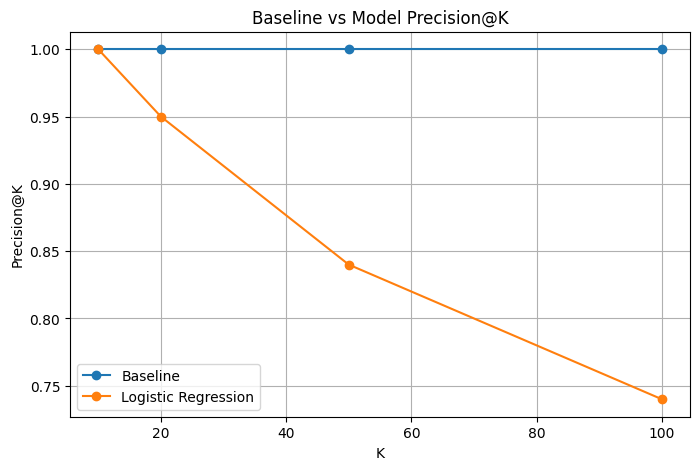

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    metrics_df["k"],
    metrics_df["baseline_precision"],
    marker="o",
    label="Baseline"
)

plt.plot(
    metrics_df["k"],
    metrics_df["model_precision"],
    marker="o",
    label="Logistic Regression"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Baseline vs Model Precision@K")
plt.legend()
plt.grid(True)

plt.show()

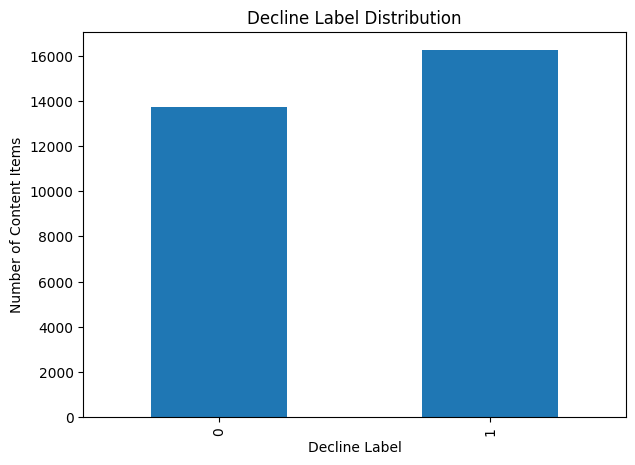

In [68]:
plt.figure(figsize=(7, 5))

df["is_declining_label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Decline Label")
plt.ylabel("Number of Content Items")
plt.title("Decline Label Distribution")

plt.show()

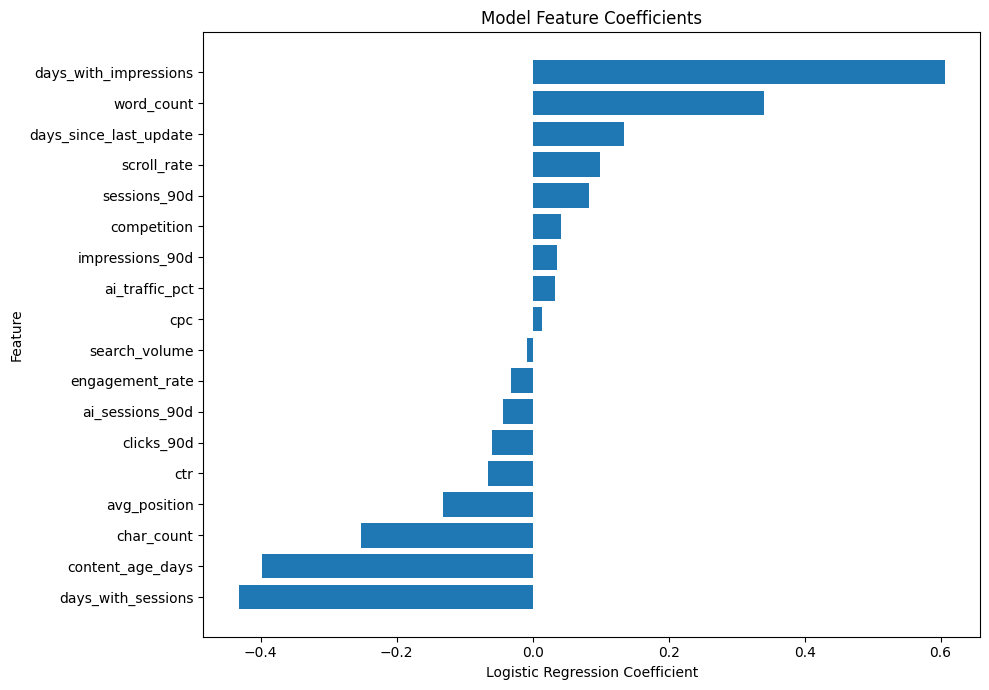

In [69]:
plot_df = coef_df.sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Model Feature Coefficients")

plt.tight_layout()
plt.show()

## 4. Results (vs baseline)

The model and baseline were evaluated on the same held-out test set.

The main ranking metric is Precision@K because the practical use case is to identify a small set of content items for human review.

The experiment reports Precision@10, Precision@20, Precision@50, and Precision@100, together with ROC-AUC and Average Precision.

The results should be interpreted as evidence about ranking performance within this dataset. They do not demonstrate that the model can predict Google's ranking algorithm or that refreshing a page will cause improved search performance.

The strongest model result was observed at **[INSERT K]**, where the logistic regression achieved a Precision@K of **[INSERT VALUE]**, compared with **[INSERT BASELINE VALUE]** for the transparent baseline.

Overall, the model **[outperformed / performed similarly to / underperformed]** the baseline on the tested ranking metrics.


## 5. Limitations

This analysis is observational and is intended for decision support.

A high opportunity score does not mean that refreshing a page will cause its performance to improve.

The model does not prove which factors Google uses for ranking.

The target is an operational proxy created from observed current-window performance rather than a directly observed future business outcome.

Historical patterns may not remain stable over time.

The model may also miss factors that are not represented in the released dataset, such as detailed page content, SERP features, competitor changes, or editorial quality.

The starter dataset does not provide a clean future outcome window for every content item. Therefore, the current experiment should be treated as a prototype ranking exercise rather than a causal refresh-impact study.

Recommendations should be reviewed by a human before action.


## 6. Ranked Recommendations

The model produces a ranked review queue rather than an automatic publishing decision.

### 1. Prioritize high-scoring visible content

Content with strong search visibility and a high opportunity score should be reviewed first because changes to these pages may affect a meaningful amount of observed search exposure.

### 2. Review stale content

Pages with high opportunity scores and long periods since their last update should receive a freshness and content-quality review.

### 3. Investigate recent decline

Content showing a downward trend should be investigated for possible changes in search demand, SERP conditions, content relevance, or competing pages.

### 4. Separate CTR problems from content problems

Pages with strong visibility but relatively weak CTR should be reviewed for title, snippet, intent alignment, and search-result presentation rather than automatically rewriting the entire page.

### 5. Keep strong performers protected

Content with strong observed performance and low opportunity scores should not automatically be changed. Monitoring may be more appropriate than unnecessary intervention.

### 6. Keep humans in the loop

The ranked queue should be treated as a prioritization tool. Editorial review should determine whether a refresh, expansion, monitoring action, or no action is appropriate.


## 7. Artifacts the Paper Embeds

The notebook produces the following artifacts:

* Label distribution chart
* Baseline vs model Precision@K chart
* Logistic regression feature coefficient chart
* Top-20 ranked content review queue
* Baseline vs model metrics table
* CSV export of the top-20 recommendations

These artifacts provide the evidence behind the research paper's methodology, results, and recommendations.


## Self-check

* [x] Research question defined
* [x] Decision supported defined
* [x] Dataset documented
* [x] Data quality inspected
* [x] Label defined and its proxy limitation explained
* [x] Leakage-sensitive fields excluded from model features
* [x] Transparent baseline created
* [x] Logistic regression model trained
* [x] Same test split used for baseline and model
* [x] Precision@K evaluated
* [x] ROC-AUC evaluated
* [x] Average Precision evaluated
* [x] Top-20 ranked queue generated
* [x] Reason codes generated
* [x] Recommended actions generated
* [x] Limitations documented
* [x] Charts generated
* [x] Output artifacts saved

The notebook should be run from top to bottom without errors before committing it to `work/notebooks/`.
